# BOAMP standardized notices and procurement episode evidence audit

**Scope.** This notebook audits the schema-aware 2015-2025 BOAMP notice layer and the conservative deterministic procurement-episode reconstruction. It does not classify digital contracts, infer renewals, tune linkage models, or perform survival analysis.

**Decision question.** Are extraction coverage and episode reconstruction defensible enough to begin the next methodological stage?

## 1. Reproducible setup

All figures are written to `data/processed/boamp_v2/figures/standardized_notice_episode_audit/`. Tables used for review are written next to the processed data.

In [1]:
from pathlib import Path
from collections import Counter
import gc
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "axes.titleweight": "bold"})

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")

DATA_DIR = PROJECT_ROOT / "data/processed/boamp_v2"
FIGURE_DIR = DATA_DIR / "figures/standardized_notice_episode_audit"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

NOTICE_PATH = DATA_DIR / "notices_standardized_2015_2025.parquet"
EPISODE_PATH = DATA_DIR / "episodes_2015_2025.parquet"
GO_NOTICE_PATH = DATA_DIR / "notices_grand_ouest.parquet"
GO_EPISODE_PATH = DATA_DIR / "episodes_grand_ouest.parquet"
NOTICE_SUMMARY_PATH = DATA_DIR / "standardized_notice_summary.json"
EPISODE_SUMMARY_PATH = DATA_DIR / "episode_reconstruction_summary.json"

for required in [NOTICE_PATH, EPISODE_PATH, NOTICE_SUMMARY_PATH, EPISODE_SUMMARY_PATH]:
    if not required.exists():
        raise FileNotFoundError(required)

def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {path.relative_to(PROJECT_ROOT)}")

notice_build = json.loads(NOTICE_SUMMARY_PATH.read_text(encoding="utf-8"))
episode_build = json.loads(EPISODE_SUMMARY_PATH.read_text(encoding="utf-8"))
pd.DataFrame({
    "check": ["Standardized notice validation", "Episode reconstruction validation", "Study start", "Study end"],
    "value": [notice_build["validation_passed"], episode_build["validation_passed"], notice_build["min_publication_date"], notice_build["max_publication_date"]],
})

,check,value
0,Standardized notice validation,True
1,Episode reconstruction validation,True
2,Study start,2015-03-02
3,Study end,2025-12-31


The build summaries are treated as acquisition and reconstruction assertions. The analytical checks below independently expose coverage, sparsity, and potentially unsafe episode groupings.

## 2. Notice-level extraction coverage

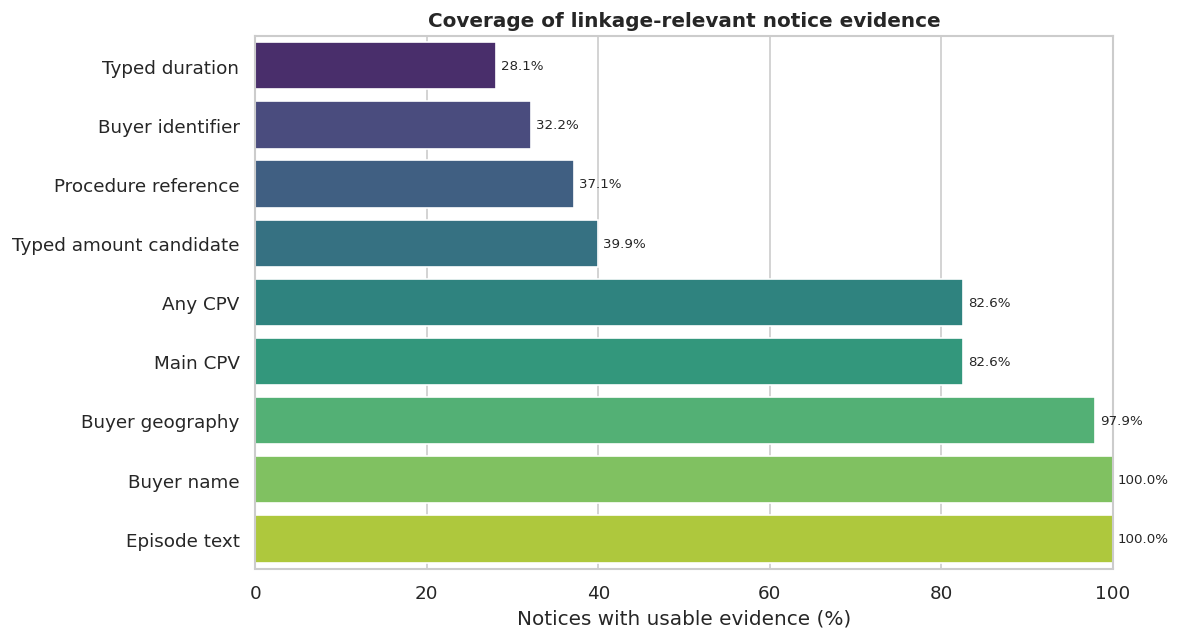

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/01_key_variable_completeness.png


,coverage_rate
Typed duration,0.280605
Buyer identifier,0.321965
Procedure reference,0.371407
Typed amount candidate,0.399094
Any CPV,0.825582
Main CPV,0.825582
Buyer geography,0.979466
Buyer name,0.999999
Episode text,1.000000


In [2]:
notice_columns = [
    "idweb", "publication_date", "source_schema", "buyer_id_source", "buyer_siren",
    "buyer_name_normalized", "buyer_department", "buyer_region", "geography_source",
    "main_cpv", "has_any_cpv", "has_episode_text", "procedure_reference",
    "duration_months", "duration_quality", "amount_candidate_count", "grand_ouest_flag",
]
notices = pd.read_parquet(NOTICE_PATH, columns=notice_columns)
notices["year"] = pd.to_datetime(notices["publication_date"]).dt.year

assert len(notices) == notice_build["rows"]
assert notices["idweb"].nunique() == len(notices)
assert notices["publication_date"].min() >= pd.Timestamp("2015-01-01").date()
assert notices["publication_date"].max() < pd.Timestamp("2026-01-01").date()

coverage = pd.Series({
    "Buyer identifier": notices["buyer_siren"].fillna("").ne("").mean(),
    "Buyer name": notices["buyer_name_normalized"].fillna("").ne("").mean(),
    "Buyer geography": notices["buyer_department"].fillna("").ne("").mean(),
    "Main CPV": notices["main_cpv"].fillna("").ne("").mean(),
    "Any CPV": notices["has_any_cpv"].fillna(False).mean(),
    "Episode text": notices["has_episode_text"].fillna(False).mean(),
    "Procedure reference": notices["procedure_reference"].fillna("").ne("").mean(),
    "Typed duration": notices["duration_months"].notna().mean(),
    "Typed amount candidate": notices["amount_candidate_count"].fillna(0).gt(0).mean(),
}).sort_values()

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(x=coverage.values * 100, y=coverage.index, hue=coverage.index, palette="viridis", legend=False)
ax.set(xlabel="Notices with usable evidence (%)", ylabel="", title="Coverage of linkage-relevant notice evidence")
ax.set_xlim(0, 100)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
save_figure("01_key_variable_completeness.png")
coverage.rename("coverage_rate").to_frame()

This chart measures evidence availability, not imputation quality. Missing identifiers, durations, amounts, and CPVs remain missing by design; later methods must include explicit missingness handling.

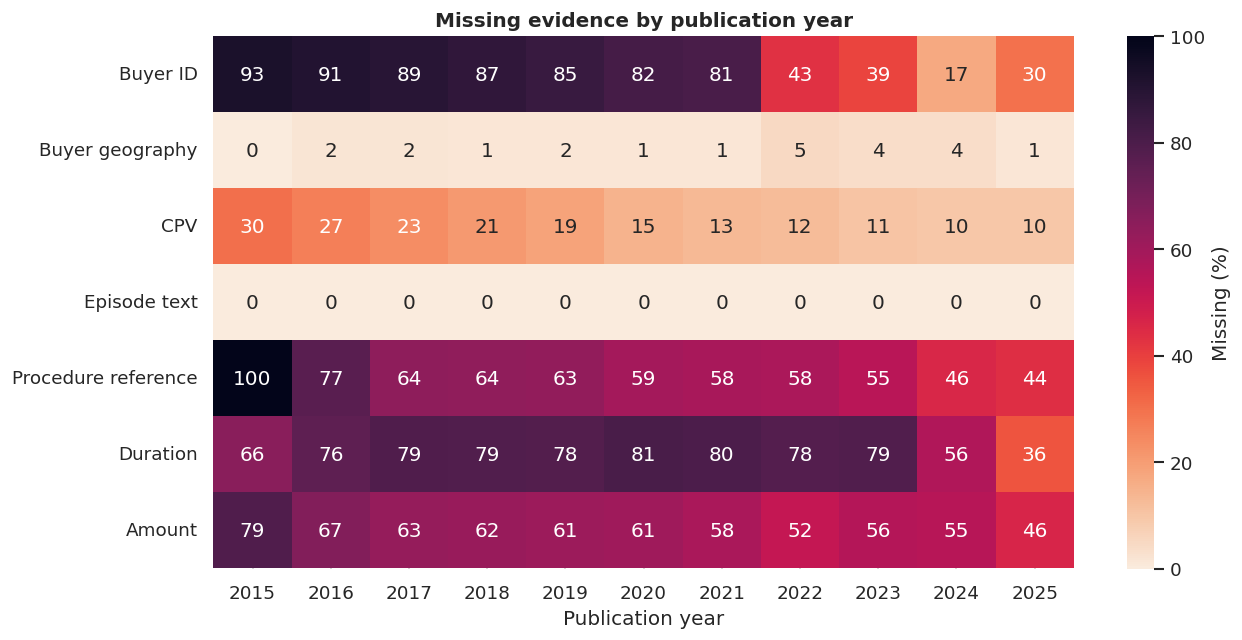

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/02_missingness_by_year.png


,Buyer ID,Buyer geography,CPV,Episode text,Procedure reference,Duration,Amount
year,,,,,,,
2015,92.75,0.00,30.08,0.0,100.00,65.61,79.27
2016,90.78,1.69,26.84,0.0,76.93,75.55,66.91
2017,89.26,1.56,23.48,0.0,64.40,79.13,62.61
2018,87.30,1.44,20.83,0.0,63.83,78.85,62.01
2019,84.78,1.53,18.66,0.0,63.30,78.30,61.26
2020,81.90,1.48,14.73,0.0,59.34,80.56,60.52
2021,80.75,1.46,12.97,0.0,58.41,80.00,57.88
2022,43.12,4.80,12.14,0.0,57.57,78.01,51.85
2023,38.98,3.64,10.52,0.0,54.51,78.78,55.53


In [3]:
missing_by_year = pd.DataFrame({
    "Buyer ID": ~notices["buyer_siren"].fillna("").ne(""),
    "Buyer geography": ~notices["buyer_department"].fillna("").ne(""),
    "CPV": ~notices["has_any_cpv"].fillna(False),
    "Episode text": ~notices["has_episode_text"].fillna(False),
    "Procedure reference": ~notices["procedure_reference"].fillna("").ne(""),
    "Duration": notices["duration_months"].isna(),
    "Amount": ~notices["amount_candidate_count"].fillna(0).gt(0),
}).assign(year=notices["year"]).groupby("year").mean() * 100

plt.figure(figsize=(11, 5.5))
sns.heatmap(missing_by_year.T, annot=True, fmt=".0f", cmap="rocket_r", vmin=0, vmax=100, cbar_kws={"label": "Missing (%)"})
plt.title("Missing evidence by publication year")
plt.xlabel("Publication year")
plt.ylabel("")
save_figure("02_missingness_by_year.png")
missing_by_year.round(2)

Year-specific changes can reflect BOAMP schema transitions rather than real procurement behavior. These patterns must be controlled for in any later temporal comparison.

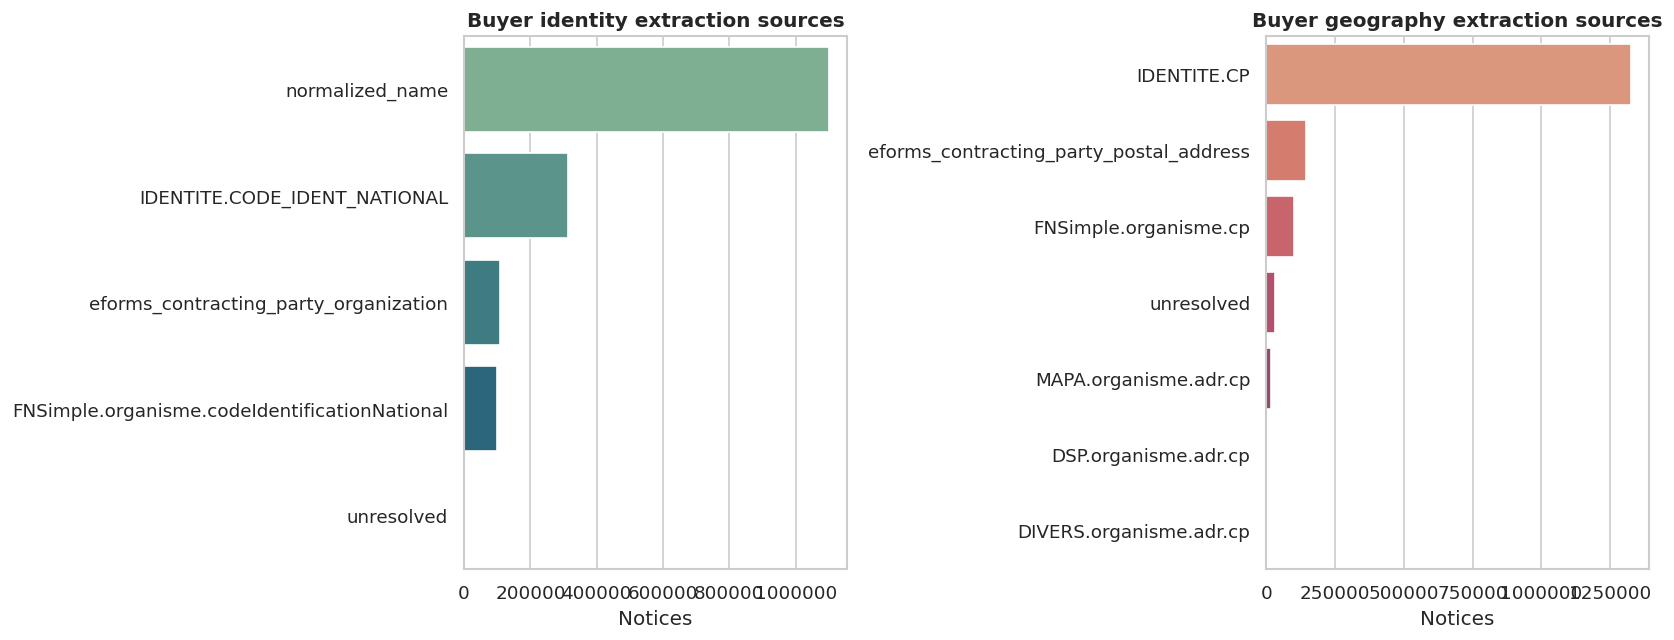

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/03_identity_and_geography_sources.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
identity = notices["buyer_id_source"].fillna("missing").replace("", "missing").value_counts().head(12)
geography = notices["geography_source"].fillna("missing").replace("", "missing").value_counts().head(12)
sns.barplot(x=identity.values, y=identity.index, ax=axes[0], hue=identity.index, palette="crest", legend=False)
sns.barplot(x=geography.values, y=geography.index, ax=axes[1], hue=geography.index, palette="flare", legend=False)
axes[0].set(title="Buyer identity extraction sources", xlabel="Notices", ylabel="")
axes[1].set(title="Buyer geography extraction sources", xlabel="Notices", ylabel="")
for ax in axes:
    ax.ticklabel_format(style="plain", axis="x")
save_figure("03_identity_and_geography_sources.png")

Source provenance is retained because a structured organization identifier is stronger evidence than a name-only fallback. Grand Ouest inclusion uses structured buyer postal geography, not place of performance.

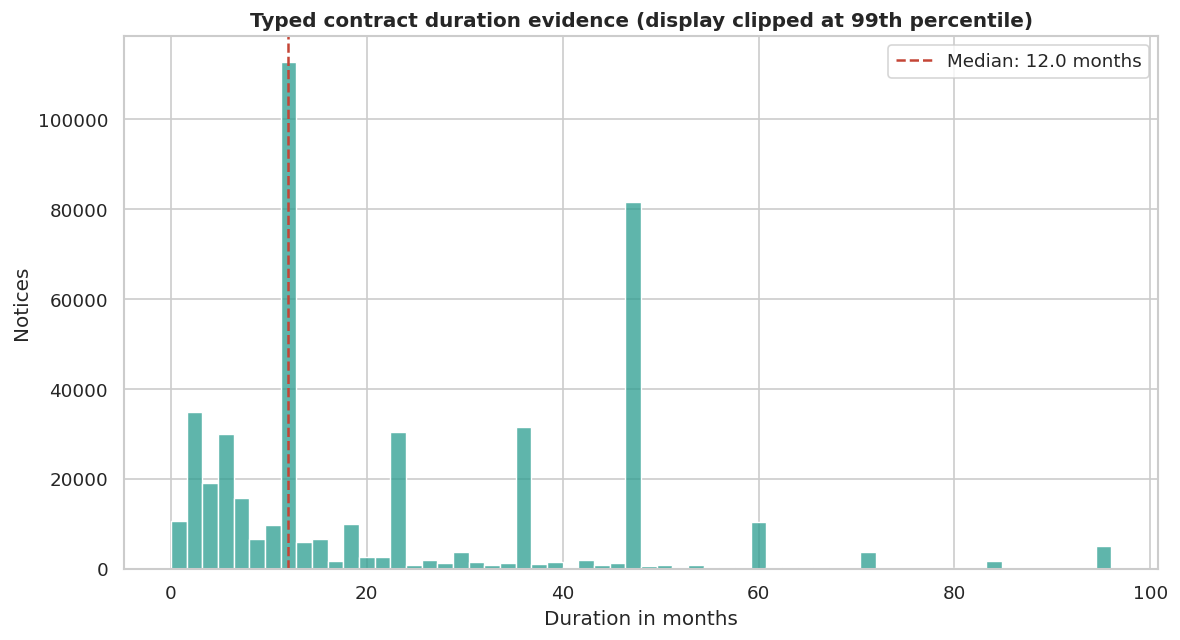

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/04_reliable_duration_distribution.png


,duration_months
count,454780.000000
mean,23.800543
std,21.789695
min,0.030000
25%,9.000000
50%,12.000000
75%,38.000000
90%,48.000000
95%,59.930000
99%,96.000000


In [5]:
reliable_duration = notices.loc[
    notices["duration_months"].notna() & notices["duration_quality"].fillna("").str.startswith("typed"),
    "duration_months",
].astype(float)
upper = reliable_duration.quantile(0.99) if len(reliable_duration) else 1
plt.figure(figsize=(10, 5.5))
sns.histplot(reliable_duration.clip(upper=upper), bins=60, color="#2a9d8f")
plt.axvline(reliable_duration.median(), color="#c44536", linestyle="--", label=f"Median: {reliable_duration.median():.1f} months")
plt.title("Typed contract duration evidence (display clipped at 99th percentile)")
plt.xlabel("Duration in months")
plt.ylabel("Notices")
plt.legend()
save_figure("04_reliable_duration_distribution.png")
reliable_duration.describe(percentiles=[.25, .5, .75, .9, .95, .99]).to_frame("duration_months")

No default duration has been inserted. The distribution is only descriptive evidence from schema-typed duration fields; extreme values remain in the data even though the display is clipped.

In [6]:
notice_audit = {
    "notice_rows": int(len(notices)),
    "unique_idweb": int(notices["idweb"].nunique()),
    "min_publication_date": str(notices["publication_date"].min()),
    "max_publication_date": str(notices["publication_date"].max()),
    "grand_ouest_notice_rows": int(notices["grand_ouest_flag"].fillna(False).sum()),
    "coverage": {key: float(value) for key, value in coverage.items()},
}
del notices
gc.collect()
notice_audit

{'notice_rows': 1620712,
 'unique_idweb': 1620712,
 'min_publication_date': '2015-03-02',
 'max_publication_date': '2025-12-31',
 'grand_ouest_notice_rows': 209502,
 'coverage': {'Typed duration': 0.280605067402475,
  'Buyer identifier': 0.3219652843935258,
  'Procedure reference': 0.37140713464205855,
  'Typed amount candidate': 0.3990937316438701,
  'Any CPV': 0.8255822132494854,
  'Main CPV': 0.8255822132494854,
  'Buyer geography': 0.9794658150245078,
  'Buyer name': 0.9999993829872303,
  'Episode text': 1.0}}

## 3. Episode reconstruction evidence

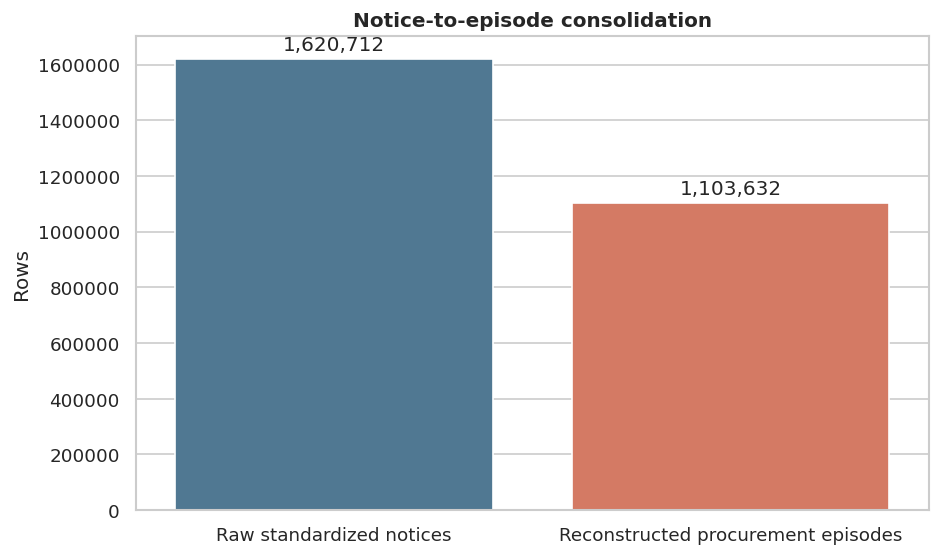

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/05_notice_episode_reduction.png


,Layer,Rows
0,Raw standardized notices,1620712
1,Reconstructed procurement episodes,1103632


In [7]:
episode_columns = [
    "episode_id", "notice_count", "episode_origin_date", "episode_last_notice_date",
    "episode_span_days", "episode_notice_natures_json", "episode_reconstruction_method",
    "episode_reconstruction_quality", "buyer_conflict_flag", "procedure_reference_conflict_flag",
    "duration_conflict_flag", "impossible_chronology_flag", "grand_ouest_flag",
]
episodes = pd.read_parquet(EPISODE_PATH, columns=episode_columns)
assert len(episodes) == episode_build["episode_rows"]

comparison = pd.DataFrame({
    "Layer": ["Raw standardized notices", "Reconstructed procurement episodes"],
    "Rows": [notice_audit["notice_rows"], len(episodes)],
})
plt.figure(figsize=(8, 4.8))
ax = sns.barplot(data=comparison, x="Layer", y="Rows", hue="Layer", palette=["#457b9d", "#e76f51"], legend=False)
ax.set(title="Notice-to-episode consolidation", xlabel="", ylabel="Rows")
ax.ticklabel_format(style="plain", axis="y")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
save_figure("05_notice_episode_reduction.png")
comparison

An episode is not a renewal link. It consolidates notices belonging to the same procurement procedure before any successor search. A small reduction is expected when source identifiers and explicit notice links are sparse.

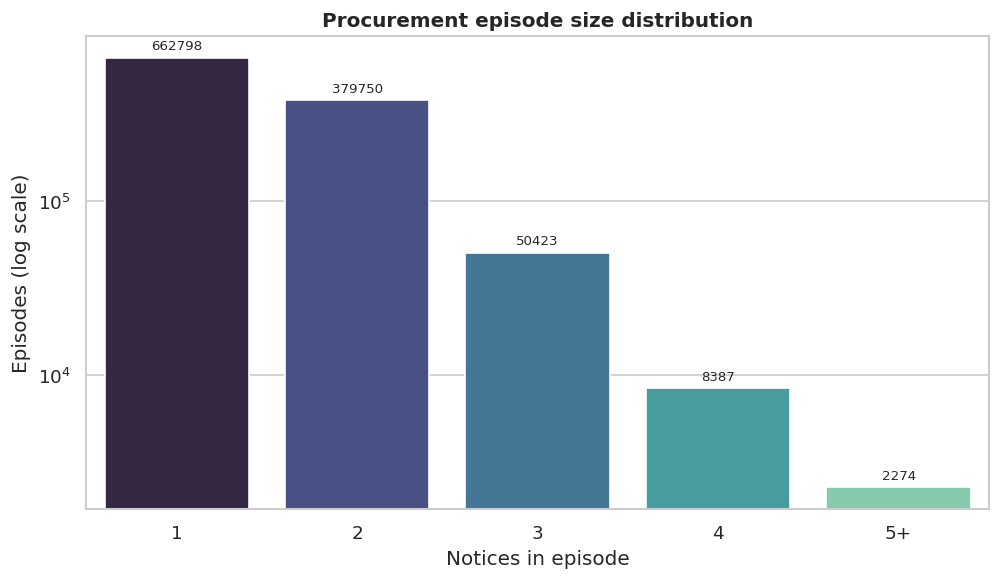

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/06_notices_per_episode.png


,episodes
notice_count,
1,662798
2,379750
3,50423
4,8387
5+,2274


In [8]:
size_bucket = pd.cut(episodes["notice_count"], bins=[0, 1, 2, 3, 4, np.inf], labels=["1", "2", "3", "4", "5+"]).value_counts().sort_index()
plt.figure(figsize=(8.5, 5))
ax = sns.barplot(x=size_bucket.index.astype(str), y=size_bucket.values, hue=size_bucket.index.astype(str), palette="mako", legend=False)
ax.set_yscale("log")
ax.set(title="Procurement episode size distribution", xlabel="Notices in episode", ylabel="Episodes (log scale)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)
save_figure("06_notices_per_episode.png")
size_bucket.rename("episodes").to_frame()

Singletons are retained as valid unresolved episodes. They are not forced into groups merely to increase apparent linkage coverage.

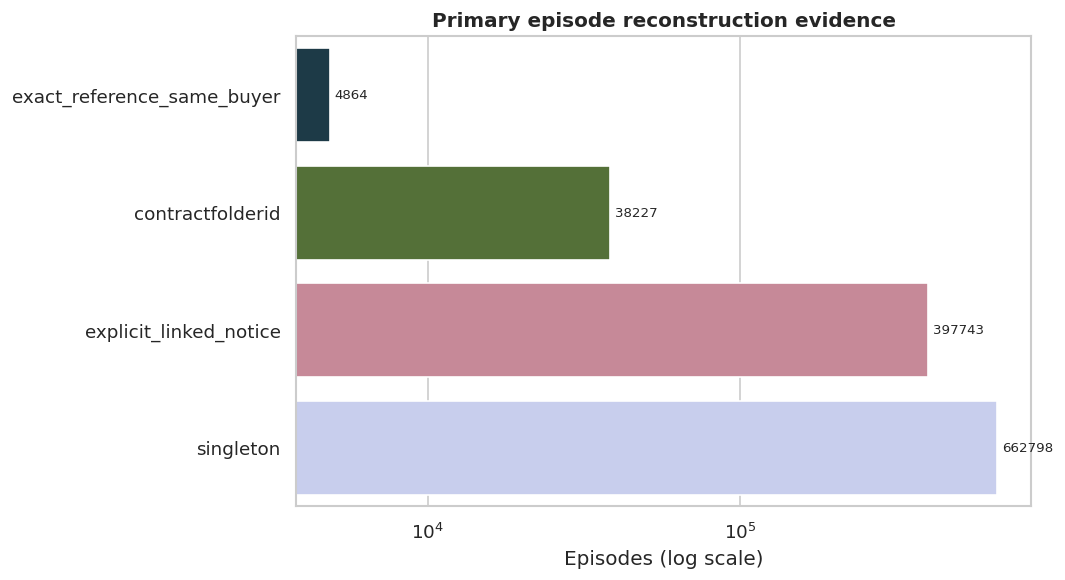

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/07_episode_reconstruction_methods.png


,episodes
episode_reconstruction_method,
exact_reference_same_buyer,4864
contractfolderid,38227
explicit_linked_notice,397743
singleton,662798


In [9]:
methods = episodes["episode_reconstruction_method"].value_counts().sort_values()
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=methods.values, y=methods.index, hue=methods.index, palette="cubehelix", legend=False)
ax.set_xscale("log")
ax.set(title="Primary episode reconstruction evidence", xlabel="Episodes (log scale)", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)
save_figure("07_episode_reconstruction_methods.png")
methods.rename("episodes").to_frame()

Evidence priority is contract folder ID, then explicit linked-notice ID, then exact procedure reference within the same buyer key, exact normalized buyer name, and a 730-day adjacency window. Trusted buyer conflicts reject an edge at component level.

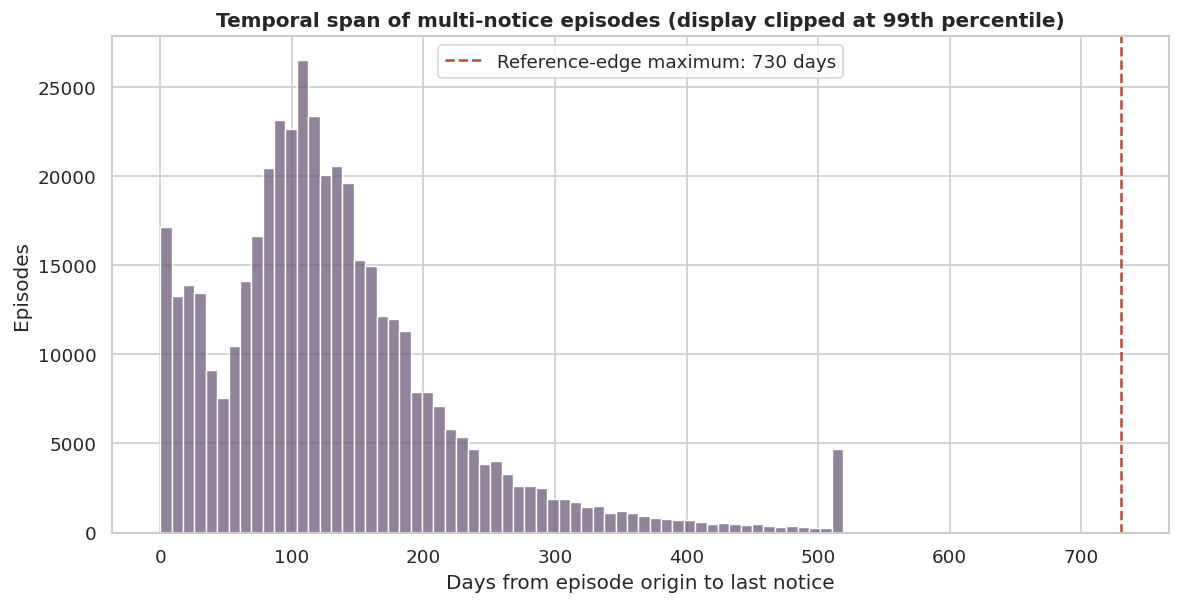

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/08_multi_notice_episode_spans.png


,span_days
count,440834.000000
mean,134.656730
std,109.520005
min,0.000000
50%,117.000000
75%,169.000000
90%,242.000000
95%,308.000000
99%,519.000000
max,3342.000000


In [10]:
multi = episodes.loc[episodes["notice_count"].gt(1)].copy()
span_upper = multi["episode_span_days"].quantile(.99) if len(multi) else 1
plt.figure(figsize=(10, 5.2))
sns.histplot(multi["episode_span_days"].dropna().clip(upper=span_upper), bins=60, color="#6d597a")
plt.axvline(730, color="#c44536", linestyle="--", label="Reference-edge maximum: 730 days")
plt.title("Temporal span of multi-notice episodes (display clipped at 99th percentile)")
plt.xlabel("Days from episode origin to last notice")
plt.ylabel("Episodes")
plt.legend()
save_figure("08_multi_notice_episode_spans.png")
multi["episode_span_days"].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame("span_days")

An episode can exceed 730 days through multiple trusted edges; the 730-day limit applies to each exact-reference adjacency, not necessarily to the final component span. Long components are therefore review evidence, not automatic errors.

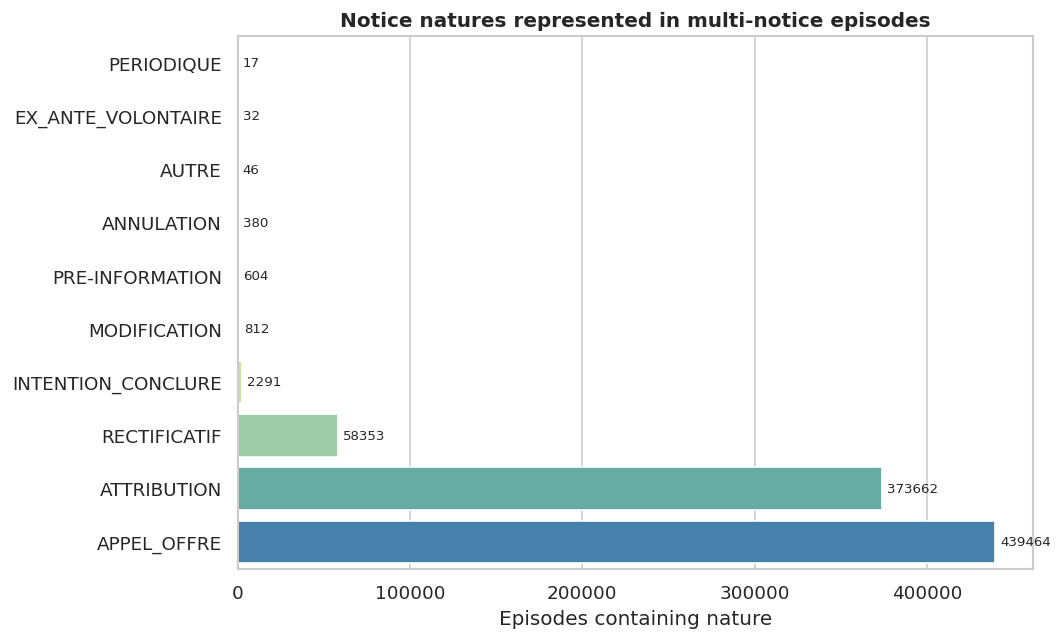

Saved: data/processed/boamp_v2/figures/standardized_notice_episode_audit/09_multi_episode_nature_composition.png


,episodes
PERIODIQUE,17
EX_ANTE_VOLONTAIRE,32
AUTRE,46
ANNULATION,380
PRE-INFORMATION,604
MODIFICATION,812
INTENTION_CONCLURE,2291
RECTIFICATIF,58353
ATTRIBUTION,373662
APPEL_OFFRE,439464


In [11]:
def parse_natures(value):
    try:
        parsed = json.loads(value or "[]")
        return parsed if isinstance(parsed, list) else []
    except json.JSONDecodeError:
        return []

nature_counts = Counter(nature for value in multi["episode_notice_natures_json"] for nature in parse_natures(value))
nature_series = pd.Series(nature_counts).sort_values(ascending=False).head(12).sort_values()
plt.figure(figsize=(9, 5.5))
ax = sns.barplot(x=nature_series.values, y=nature_series.index, hue=nature_series.index, palette="Spectral", legend=False)
ax.set(title="Notice natures represented in multi-notice episodes", xlabel="Episodes containing nature", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)
save_figure("09_multi_episode_nature_composition.png")
nature_series.rename("episodes").to_frame()

Nature composition provides a quick semantic check that reconstructed episodes combine plausible procurement-stage notices rather than unrelated records with a coincidental identifier.

## 4. Suspicious episodes and decision gate

In [12]:
suspicious = episodes.loc[
    episodes["buyer_conflict_flag"].fillna(False)
    | episodes["impossible_chronology_flag"].fillna(False)
    | episodes["procedure_reference_conflict_flag"].fillna(False)
    | episodes["notice_count"].ge(10)
    | episodes["episode_span_days"].fillna(0).gt(2922)
].sort_values(["notice_count", "episode_span_days"], ascending=False)

suspicious_path = DATA_DIR / "episode_reconstruction_review_cases.csv"
suspicious.to_csv(suspicious_path, index=False, encoding="utf-8")
print(f"Saved {len(suspicious):,} review cases to {suspicious_path.relative_to(PROJECT_ROOT)}")
suspicious.head(30)

Saved 3,344 review cases to data/processed/boamp_v2/episode_reconstruction_review_cases.csv


,episode_id,notice_count,episode_origin_date,episode_last_notice_date,episode_span_days,episode_notice_natures_json,episode_reconstruction_method,episode_reconstruction_quality,buyer_conflict_flag,procedure_reference_conflict_flag,duration_conflict_flag,impossible_chronology_flag,grand_ouest_flag
821885,EP-7d3b9f1a5b15e4ad,79,2018-09-08,2021-01-09,854,"[""APPEL_OFFRE"",""ATTRIBUTION"",""RECTIFICATIF""]",explicit_linked_notice,high,False,True,False,False,True
889547,EP-4f76c6a850d5eb9f,65,2020-03-12,2023-08-24,1260,"[""APPEL_OFFRE"",""ATTRIBUTION"",""RECTIFICATIF""]",explicit_linked_notice,high,False,True,False,False,False
777006,EP-319b524cfdc3a18b,61,2017-09-02,2021-02-25,1272,"[""APPEL_OFFRE"",""ATTRIBUTION""]",explicit_linked_notice,high,False,True,False,False,True
733598,EP-00b97332246611a6,59,2016-09-05,2021-02-25,1634,"[""APPEL_OFFRE"",""ATTRIBUTION""]",explicit_linked_notice,high,False,True,False,False,True
739936,EP-a1aa4975cdb678f5,45,2016-10-22,2022-01-15,1911,"[""APPEL_OFFRE"",""ATTRIBUTION""]",explicit_linked_notice,high,False,True,False,False,False
785111,EP-087aede765e38ee1,35,2017-11-02,2022-12-31,1885,"[""APPEL_OFFRE"",""ATTRIBUTION"",""MODIFICATION""]",explicit_linked_notice,high,False,False,False,False,False
728092,EP-47b6fe8c2e53a441,32,2016-07-15,2019-08-10,1121,"[""APPEL_OFFRE"",""ATTRIBUTION"",""RECTIFICATIF""]",explicit_linked_notice,high,False,True,False,False,False
950521,EP-b2f2665a0326e9fe,30,2021-09-05,2023-09-03,728,"[""APPEL_OFFRE"",""ATTRIBUTION""]",explicit_linked_notice,high,False,False,False,False,True
824668,EP-6cff89c4d9a6c7cd,28,2018-09-29,2022-11-25,1518,"[""APPEL_OFFRE"",""ATTRIBUTION"",""RECTIFICATIF""]",explicit_linked_notice,high,False,False,False,False,False
908225,EP-1d84237e97dc84c9,28,2020-09-11,2023-07-21,1043,"[""APPEL_OFFRE"",""ATTRIBUTION"",""MODIFICATION""]",explicit_linked_notice,high,False,True,False,False,False


The exported table is an audit queue, not new ground truth. Large, long, or internally conflicting components should be checked before episode-derived variables are used for linkage.

In [13]:
audit_metrics = {
    **notice_audit,
    "episode_rows": int(len(episodes)),
    "grand_ouest_episode_rows": int(episodes["grand_ouest_flag"].fillna(False).sum()),
    "singleton_share": float(episodes["notice_count"].eq(1).mean()),
    "multi_notice_episode_rows": int(episodes["notice_count"].gt(1).sum()),
    "max_notice_count": int(episodes["notice_count"].max()),
    "max_episode_span_days": int(episodes["episode_span_days"].fillna(0).max()),
    "buyer_conflict_episodes": int(episodes["buyer_conflict_flag"].fillna(False).sum()),
    "impossible_chronology_episodes": int(episodes["impossible_chronology_flag"].fillna(False).sum()),
    "reference_conflict_episodes": int(episodes["procedure_reference_conflict_flag"].fillna(False).sum()),
    "suspicious_review_cases": int(len(suspicious)),
}
structural_checks = {
    "notice_build_valid": bool(notice_build["validation_passed"]),
    "episode_build_valid": bool(episode_build["validation_passed"]),
    "all_notices_assigned_once": bool(episode_build["all_notices_assigned_once"]),
    "no_buyer_conflict_components": audit_metrics["buyer_conflict_episodes"] == 0,
    "no_impossible_chronology": audit_metrics["impossible_chronology_episodes"] == 0,
}
audit_metrics["structural_checks"] = structural_checks
audit_metrics["structurally_ready_for_methodology_review"] = all(structural_checks.values())
metrics_path = DATA_DIR / "standardized_notice_episode_audit_metrics.json"
metrics_path.write_text(json.dumps(audit_metrics, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")

pd.DataFrame({"Check": structural_checks.keys(), "Passed": structural_checks.values()})

,Check,Passed
0,notice_build_valid,True
1,episode_build_valid,True
2,all_notices_assigned_once,True
3,no_buyer_conflict_components,True
4,no_impossible_chronology,True


## 5. Evidence-based conclusion

Passing the structural gate means the standardized layer and episode mapping are reproducible and internally coherent enough for methodology review. It does **not** validate renewal linkage, establish digital-market labels, or authorize survival analysis. The next action is to inspect the exported suspicious episode cases and extraction coverage, freeze any justified corrections, and only then define the study cohort and successor-link benchmark.

In [14]:
if audit_metrics["structurally_ready_for_methodology_review"]:
    decision = "READY FOR METHODOLOGY REVIEW, NOT YET READY FOR RENEWAL OR SURVIVAL INFERENCE"
else:
    decision = "STOP: STRUCTURAL AUDIT FAILED"
print(decision)
print(f"Figures: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Audit metrics: {metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Review cases: {suspicious_path.relative_to(PROJECT_ROOT)}")

READY FOR METHODOLOGY REVIEW, NOT YET READY FOR RENEWAL OR SURVIVAL INFERENCE
Figures: data/processed/boamp_v2/figures/standardized_notice_episode_audit
Audit metrics: data/processed/boamp_v2/standardized_notice_episode_audit_metrics.json
Review cases: data/processed/boamp_v2/episode_reconstruction_review_cases.csv
